# Cancer Mortality Rate


# 1) Problem Description

In this case we will try to predict cancer mortality rates in US counties. In addition to that, we will try to answer some other questions by EDA, such as:

- What features causes the mortality rate to be higher / lower?

- Are some counties totally different than others?

- Which race, are most dangered by cancer?

And many many more.


All the data with column explanation is available here: https://data.world/nrippner/ols-regression-challenge. 

# 2) Basic Imports and preparation for Data Exploration

General Imports for Data Clearing, And Data Exploratory

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import re


Setting up the display of Data Frames and plots.

In [185]:
pd.set_option("display.width",320)
pd.set_option("display.max_columns",40)
sns.set_style("whitegrid")

Reading the DataFrame

In [186]:
raw_data = pd.read_csv("cancer_reg.csv", encoding="windows-1250")

raw_data.head()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,binnedInc,MedianAge,MedianAgeMale,MedianAgeFemale,Geography,AvgHouseholdSize,PercentMarried,PctNoHS18_24,PctHS18_24,PctSomeCol18_24,PctBachDeg18_24,PctHS25_Over,PctBachDeg25_Over,PctEmployed16_Over,PctUnemployed16_Over,PctPrivateCoverage,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
0,1397.0,469,164.9,489.8,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,36.9,41.7,"Kitsap County, Washington",2.54,52.5,11.5,39.5,42.1,6.9,23.2,19.6,51.9,8.0,75.1,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,173.0,70,161.3,411.6,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,32.2,33.7,"Kittitas County, Washington",2.34,44.5,6.1,22.4,64.0,7.5,26.0,22.7,55.9,7.8,70.2,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,102.0,50,174.7,349.7,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,44.0,45.8,"Klickitat County, Washington",2.62,54.2,24.0,36.6,NaN,9.5,29.0,16.0,45.9,7.0,63.7,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,427.0,202,194.8,430.4,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,42.2,43.4,"Lewis County, Washington",2.52,52.7,20.2,41.2,36.1,2.5,31.6,9.3,48.3,12.1,58.4,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,57.0,26,144.4,350.1,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,47.8,48.9,"Lincoln County, Washington",2.34,57.8,14.9,43.0,40.0,2.0,33.4,15.0,48.2,4.8,61.6,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657


# 3) Data Cleaning and General Information about Dataset.

In [187]:
print(f"In dataset we have:\n{raw_data.shape[0]} rows,\n{raw_data.shape[1]} features.")

In dataset we have:
3047 rows,
34 features.


3.1 Checking the Datatypes of Dataset.

In [188]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avgAnnCount              3047 non-null   float64
 1   avgDeathsPerYear         3047 non-null   int64  
 2   TARGET_deathRate         3047 non-null   float64
 3   incidenceRate            3047 non-null   float64
 4   medIncome                3047 non-null   int64  
 5   popEst2015               3047 non-null   int64  
 6   povertyPercent           3047 non-null   float64
 7   studyPerCap              3047 non-null   float64
 8   binnedInc                3047 non-null   object 
 9   MedianAge                3047 non-null   float64
 10  MedianAgeMale            3047 non-null   float64
 11  MedianAgeFemale          3047 non-null   float64
 12  Geography                3047 non-null   object 
 13  AvgHouseholdSize         3047 non-null   float64
 14  PercentMarried          

In [189]:
print(raw_data['binnedInc'].head()) # For this column, we will only grab the median value. We're not intreset in decyl value. We will do this using regular expression.


REGEX_PATTERN = "(?<=\(|\[)\d*\.{0,1}\d{0,900}"


raw_data['medianInc']=[re.search(REGEX_PATTERN, raw_data['binnedInc'][i]).group() for i in range(len(raw_data))]

raw_data['medianInc'] = raw_data['medianInc'].astype(float)

raw_data = raw_data.drop("binnedInc",axis=1)




0     (61494.5, 125635]
1    (48021.6, 51046.4]
2    (48021.6, 51046.4]
3      (42724.4, 45201]
4    (48021.6, 51046.4]
Name: binnedInc, dtype: object


<>:4: SyntaxWarning: invalid escape sequence '\('
<>:4: SyntaxWarning: invalid escape sequence '\('
/var/folders/n6/www0gbg912s1hbz7rz_kh0vc0000gn/T/ipykernel_1462/3531550370.py:4: SyntaxWarning: invalid escape sequence '\('
  REGEX_PATTERN = "(?<=\(|\[)\d*\.{0,1}\d{0,900}"


3.2 Checking Null Values in Dataset

In [190]:


[f"{col} - {np.round(raw_data[col].isnull().sum() / raw_data.shape[0],2)}% empty values" for col in raw_data.columns[raw_data.isnull().any()]]

['PctSomeCol18_24 - 0.75% empty values',
 'PctEmployed16_Over - 0.05% empty values',
 'PctPrivateCoverageAlone - 0.2% empty values']

In terms of <b> PctSomeCol18_24 </b> we will delete this column, since there's too much empty values. Fo other columns, we will fill them with nanmedian value.

In [191]:
PCT_EMPLOYED_NANMEDIAN = np.nanmedian(raw_data["PctEmployed16_Over"])
PCT_PRIVATE_NANMEDIAN = np.nanmedian(raw_data["PctPrivateCoverageAlone"])

print(f"Employed Nanmedian: {np.round(PCT_EMPLOYED_NANMEDIAN,3)}\nPrivate Coverage Nanmedian: {PCT_PRIVATE_NANMEDIAN}")

raw_data = raw_data.drop("PctSomeCol18_24",axis=1)
raw_data["PctEmployed16_Over"] = raw_data['PctEmployed16_Over'].fillna(PCT_EMPLOYED_NANMEDIAN)
raw_data["PctPrivateCoverageAlone"]=raw_data["PctPrivateCoverageAlone"].fillna(PCT_PRIVATE_NANMEDIAN)


print(f"Number of Empty Values in dataset: {raw_data.isnull().sum().sum()}")

clean_data = raw_data.copy()

Employed Nanmedian: 54.5
Private Coverage Nanmedian: 48.7
Number of Empty Values in dataset: 0


# 4. Exploratory Data Analysis / Feature Engineering


We will begin exploratory Data Analysis by checking the descriptive sastistics of the whole dataframe.

In [192]:
stats = clean_data.describe()
stats.loc['V'] = stats.loc['std'] / stats.loc['mean']
stats

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,MedianAge,MedianAgeMale,MedianAgeFemale,AvgHouseholdSize,PercentMarried,PctNoHS18_24,PctHS18_24,PctBachDeg18_24,PctHS25_Over,PctBachDeg25_Over,PctEmployed16_Over,PctUnemployed16_Over,PctPrivateCoverage,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate,medianInc
count,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3.047000e+03,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000
mean,606.338544,185.965868,178.664063,448.268586,47063.281917,1.026374e+05,16.878175,155.399415,45.272333,39.570725,42.145323,2.479662,51.773679,18.224450,35.002068,6.158287,34.804660,13.282015,54.169970,7.852412,64.354939,48.502987,41.196324,36.252642,19.240072,83.645286,9.107978,1.253965,1.983523,51.243872,5.640306,43752.766328
std,1416.356223,504.134286,27.751511,54.560733,12040.090836,3.290592e+05,6.409087,529.628366,45.304480,5.226017,5.292849,0.429174,6.896928,8.093064,9.069722,4.529059,7.034924,5.394756,8.105295,3.452371,10.647057,9.019423,9.447687,7.841741,6.113041,16.380025,14.534538,2.610276,3.517710,6.572814,1.985816,10458.892963
min,6.000000,3.000000,59.700000,201.300000,22640.000000,8.270000e+02,3.200000,0.000000,22.300000,22.400000,22.300000,0.022100,23.100000,0.000000,0.000000,0.000000,7.500000,2.500000,17.600000,0.400000,22.300000,15.700000,13.500000,11.200000,2.600000,10.199155,0.000000,0.000000,0.000000,22.992490,0.000000,22640.000000
25%,76.000000,28.000000,161.200000,420.300000,38882.500000,1.168400e+04,12.150000,0.000000,37.700000,36.350000,39.100000,2.370000,47.750000,12.800000,29.200000,3.100000,30.400000,9.400000,48.900000,5.500000,57.200000,43.100000,34.500000,30.900000,14.850000,77.296180,0.620675,0.254199,0.295172,47.763063,4.521419,37413.800000
50%,171.000000,61.000000,178.100000,453.549422,45207.000000,2.664300e+04,15.900000,0.000000,41.000000,39.600000,42.400000,2.500000,52.400000,17.100000,34.700000,5.400000,35.300000,12.300000,54.500000,7.600000,65.100000,48.700000,41.100000,36.300000,18.800000,90.059774,2.247576,0.549812,0.826185,51.669941,5.381478,45201.000000
75%,518.000000,149.000000,195.200000,480.850000,52492.000000,6.867100e+04,20.400000,83.650776,44.000000,42.500000,45.300000,2.630000,56.400000,22.700000,40.700000,8.200000,39.650000,16.100000,60.000000,9.700000,72.100000,53.800000,47.700000,41.550000,23.100000,95.451693,10.509732,1.221037,2.177960,55.395132,6.493677,51046.400000
max,38150.000000,14010.000000,362.800000,1206.900000,125635.000000,1.017029e+07,47.400000,9762.308998,624.000000,64.700000,65.700000,3.970000,72.500000,64.100000,72.500000,51.800000,54.800000,42.200000,80.100000,29.400000,92.300000,78.900000,70.700000,65.100000,46.600000,100.000000,85.947799,42.619425,41.930251,78.075397,21.326165,61494.500000
V,2.335917,2.710897,0.155328,0.121714,0.255828,3.206037e+00,0.379726,3.408175,1.000710,0.132068,0.125586,0.173078,0.133213,0.444077,0.259120,0.735441,0.202126,0.406170,0.149627,0.439657,0.165443,0.185956,0.229333,0.216308,0.317724,0.195827,1.595803,2.081618,1.773466,0.128265,0.352076,0.239045


Based on descriptive statistics we can say, that we have a mix of scales in our dataset, some of them are measured in thousands, and some of them have really low values - this means, that in the future we will have to rescale our data. We can also say, that some of our features vary from the mean value, for example <b>studyPerCap</b> which can make our prediction a little bit more uncertain. We will deal with those features later.

Next, we will try to measure skewness.

In [193]:
skew_cols = [column for column in clean_data.columns if clean_data[column].dtype != "O" and abs(np.round(scipy.stats.skew(clean_data[column]),3)) > 0.5]

[f"{column} : {np.round(scipy.stats.skew(clean_data[column]),3)}" for column in clean_data.columns 
    if clean_data[column].dtype != "O" and abs(np.round(scipy.stats.skew(clean_data[column]),3)) > 0.5]



['avgAnnCount : 10.675',
 'avgDeathsPerYear : 11.943',
 'incidenceRate : 0.772',
 'medIncome : 1.407',
 'popEst2015 : 14.283',
 'povertyPercent : 0.93',
 'studyPerCap : 8.709',
 'MedianAge : 9.985',
 'AvgHouseholdSize : -3.379',
 'PercentMarried : -0.653',
 'PctNoHS18_24 : 0.973',
 'PctBachDeg18_24 : 1.955',
 'PctBachDeg25_Over : 1.094',
 'PctUnemployed16_Over : 0.891',
 'PctWhite : -1.68',
 'PctBlack : 2.257',
 'PctAsian : 7.414',
 'PctOtherRace : 4.95',
 'PctMarriedHouseholds : -0.522',
 'BirthRate : 1.323']

Those columns mentioned above, seems to be a little bit biased. We will try to see what's going on with them.

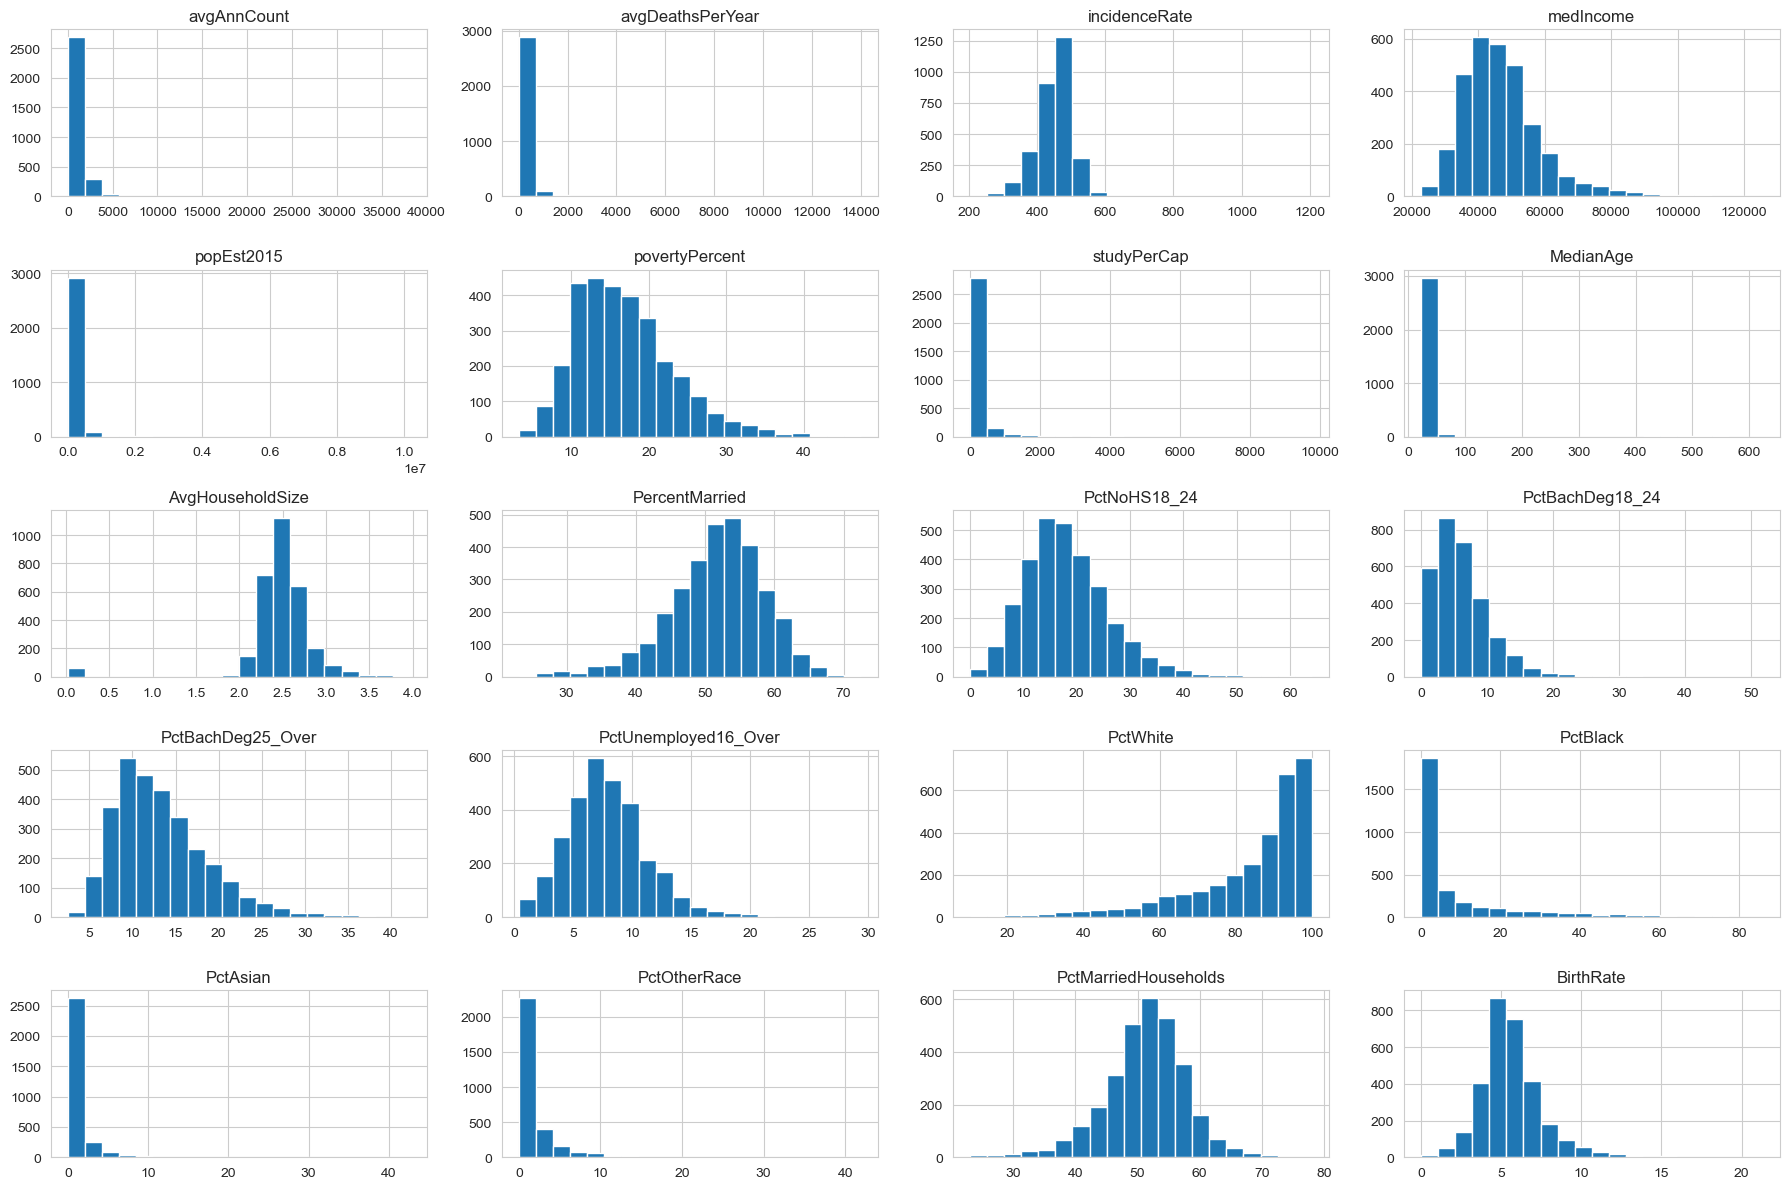

In [194]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=5, ncols=4,figsize=(18,12))

for i, col in enumerate(skew_cols):
    row_index = i // 4
    col_index = i % 4
    ax[row_index, col_index].hist(clean_data[col], bins=20)  
    ax[row_index, col_index].set_title(col) 

plt.tight_layout()
plt.show()


Infact, some of the data are really skewed. However some of them, like: "avgAnncount" are really different from other variables. And we will deal with them first.

In [195]:
clean_data['avgAnnCount'].describe() # This max value seems to be a little bit off

count     3047.000000
mean       606.338544
std       1416.356223
min          6.000000
25%         76.000000
50%        171.000000
75%        518.000000
max      38150.000000
Name: avgAnnCount, dtype: float64

In [196]:
clean_data[clean_data['avgAnnCount'] == 38150.000000] # The big value of mean number of reported cases of cancer diagnosed annually
#is caused by huge geographical region, which can correlate to estimated population in year 2015.

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,MedianAge,MedianAgeMale,MedianAgeFemale,Geography,AvgHouseholdSize,PercentMarried,PctNoHS18_24,PctHS18_24,PctBachDeg18_24,PctHS25_Over,PctBachDeg25_Over,PctEmployed16_Over,PctUnemployed16_Over,PctPrivateCoverage,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate,medianInc
999,38150.0,14010,148.4,405.5,55686,10170292,18.7,255.941521,35.6,34.4,36.8,"Los Angeles County, California",3.02,42.4,15.3,27.0,9.9,20.7,19.8,58.0,10.0,55.0,47.4,39.7,32.9,23.0,53.25871,8.27614,14.12938,19.591522,44.58165,4.705281,54545.6


In [197]:
clean_data[clean_data['popEst2015'] == clean_data['popEst2015'].max()]

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,MedianAge,MedianAgeMale,MedianAgeFemale,Geography,AvgHouseholdSize,PercentMarried,PctNoHS18_24,PctHS18_24,PctBachDeg18_24,PctHS25_Over,PctBachDeg25_Over,PctEmployed16_Over,PctUnemployed16_Over,PctPrivateCoverage,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate,medianInc
999,38150.0,14010,148.4,405.5,55686,10170292,18.7,255.941521,35.6,34.4,36.8,"Los Angeles County, California",3.02,42.4,15.3,27.0,9.9,20.7,19.8,58.0,10.0,55.0,47.4,39.7,32.9,23.0,53.25871,8.27614,14.12938,19.591522,44.58165,4.705281,54545.6


Dividing those two values will gave us a new feature, that will give us information about how often cancer is being diagnosed within given county.

In [198]:
clean_data['cancDiag'] = clean_data['popEst2015'] / clean_data['avgAnnCount']

/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprec

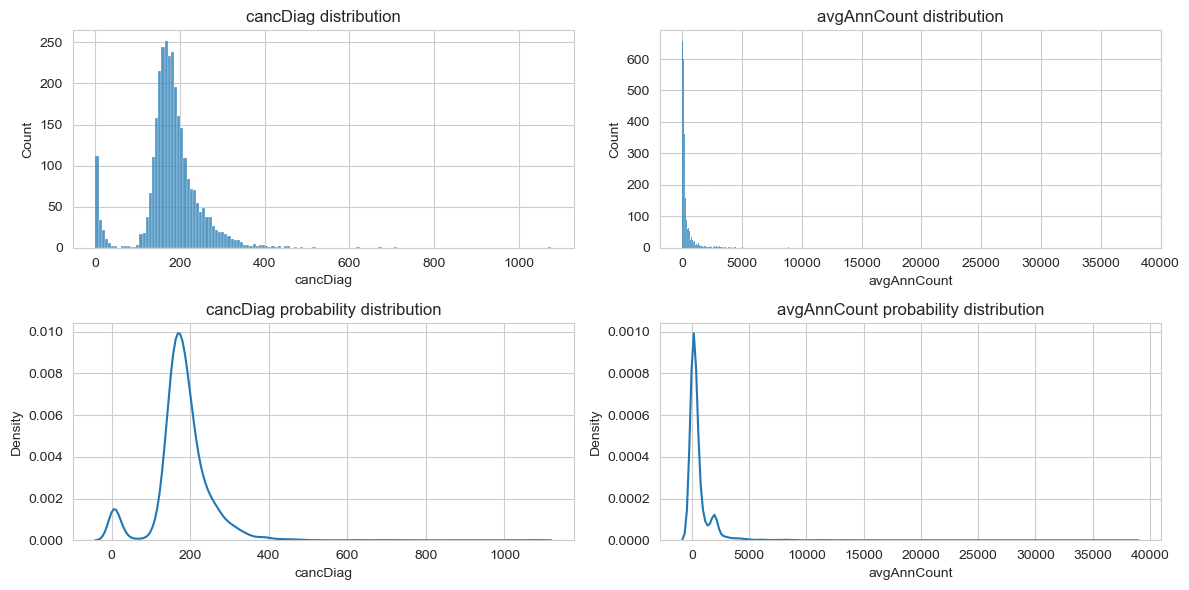

In [199]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,6))

sns.histplot(clean_data['cancDiag'],ax=ax[0,0])
ax[0,0].set_title("cancDiag distribution")


sns.histplot(clean_data['avgAnnCount'],ax=ax[0,1])
ax[0,1].set_title("avgAnnCount distribution")

sns.kdeplot(clean_data['cancDiag'],ax=ax[1,0])
ax[1,0].set_title("cancDiag probability distribution")

sns.kdeplot(clean_data['avgAnnCount'],ax=ax[1,1])
ax[1,1].set_title("avgAnnCount probability distribution")

plt.tight_layout()

In [200]:
clean_data['cancDiag'].describe()

count    3047.000000
mean      181.197192
std        69.666354
min         0.422384
25%       154.145558
50%       177.823529
75%       208.238018
max      1077.513538
Name: cancDiag, dtype: float64

In [201]:
clean_data[clean_data['cancDiag'] == np.max(clean_data['cancDiag'])][['Geography','cancDiag','avgAnnCount','popEst2015']]
#Basing on that metrics, Los Angeles is no longer the worst county.

,Geography,cancDiag,avgAnnCount,popEst2015
112,"Clark County, Nevada",1077.513538,1962.667684,2114801


We created a new feature that gives us more information about the cancer diagnosis in particular county, which would be easier to interpret that those two different variables separately. We can probably do the same with variable "avgDeathsPerYear".

/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprec

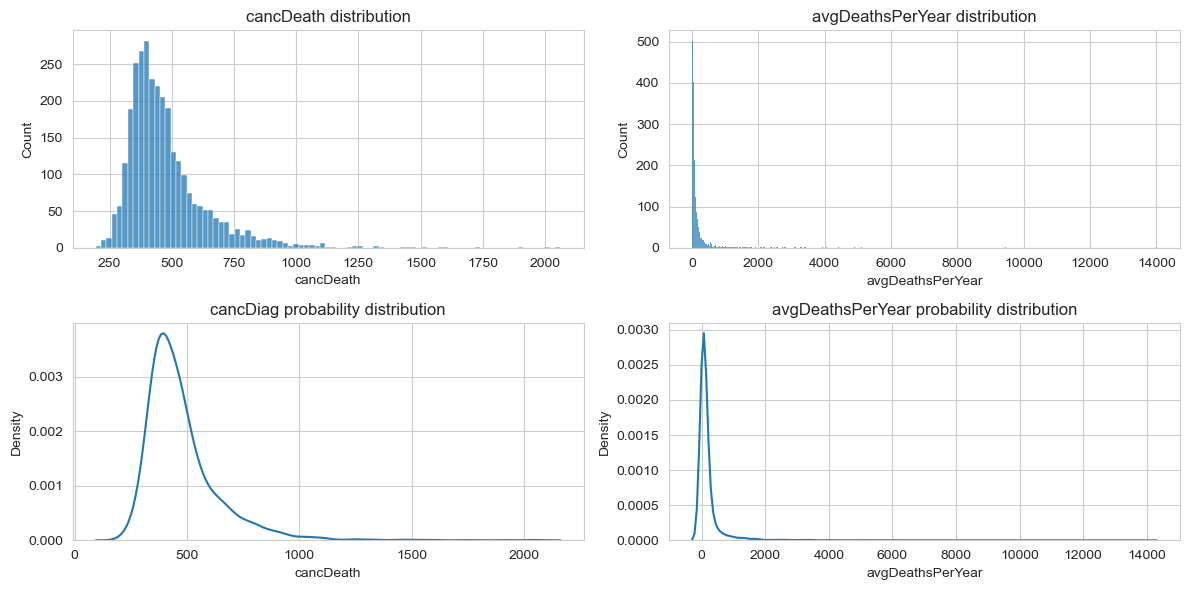

In [202]:
clean_data['cancDeath'] = clean_data['popEst2015'] / clean_data['avgDeathsPerYear']

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,6))

sns.histplot(clean_data['cancDeath'],ax=ax[0,0])
ax[0,0].set_title("cancDeath distribution")


sns.histplot(clean_data['avgDeathsPerYear'],ax=ax[0,1])
ax[0,1].set_title("avgDeathsPerYear distribution")

sns.kdeplot(clean_data['cancDeath'],ax=ax[1,0])
ax[1,0].set_title("cancDiag probability distribution")

sns.kdeplot(clean_data['avgDeathsPerYear'],ax=ax[1,1])
ax[1,1].set_title("avgDeathsPerYear probability distribution")

plt.tight_layout()

There's no more features for which we can do this transformation again. The next thing that's worrying me is feature called <b>MedianAge</b>. This feature should be not be skewed that much, since MedianAge should not be vary a lot from county to county. In fact it should look like Gaussian distribution.

Text(0, 0.5, 'Median Age')

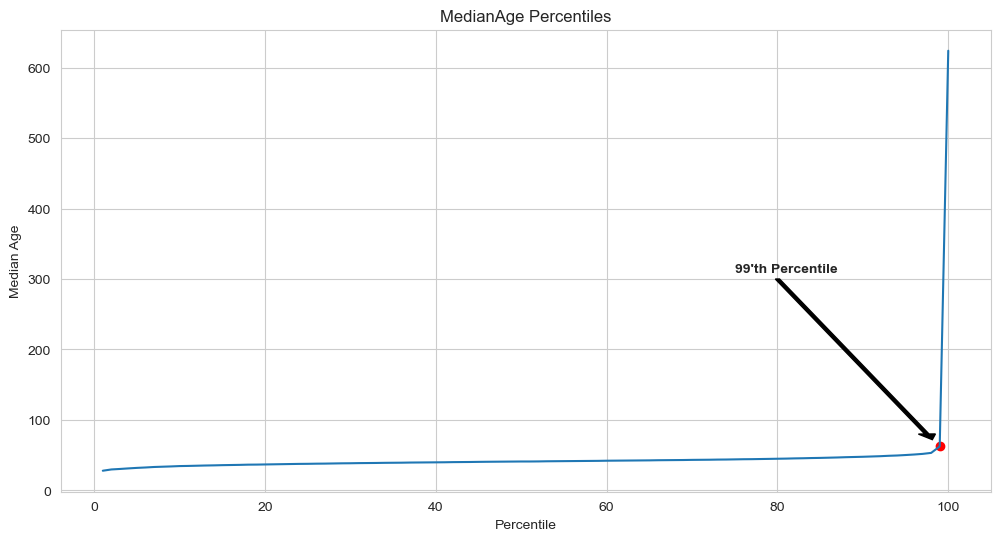

In [203]:
percentile = list(range(1,101))
value = [np.percentile(clean_data['MedianAge'],x) for x in percentile]

plt.figure(figsize=(12,6))

plt.plot(percentile,value)
plt.scatter(percentile[-2], value[-2],c='red')


plt.title("MedianAge Percentiles")
plt.arrow(80, 300, dx=17.5, dy=-220,color='black',shape='full',width=0.5,head_width=2,head_length=8)
plt.text(75,310,"99'th Percentile", fontsize=10, fontweight='bold')
plt.xlabel("Percentile")
plt.ylabel("Median Age")


As you see there's huge difference between Maximum value (100 percentile) and 99'th percentile. That's the reason why we see so much skewed data so much. We will try to replace this value with average median age where Median Age is less than 100.

In [204]:

AVG_BEFORE = np.round(clean_data['MedianAge'].describe().loc['mean'],3)

AVG_AFTER = np.round(clean_data[clean_data['MedianAge']<=100]['MedianAge'].mean(),3)


print(f"Average Median Age before slicing the data: {AVG_BEFORE}\nAverage Median Age after slicing: {AVG_AFTER}")

clean_data.loc[clean_data['MedianAge']>100, 'MedianAge'] = AVG_BEFORE


Average Median Age before slicing the data: 45.272
Average Median Age after slicing: 40.824


/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


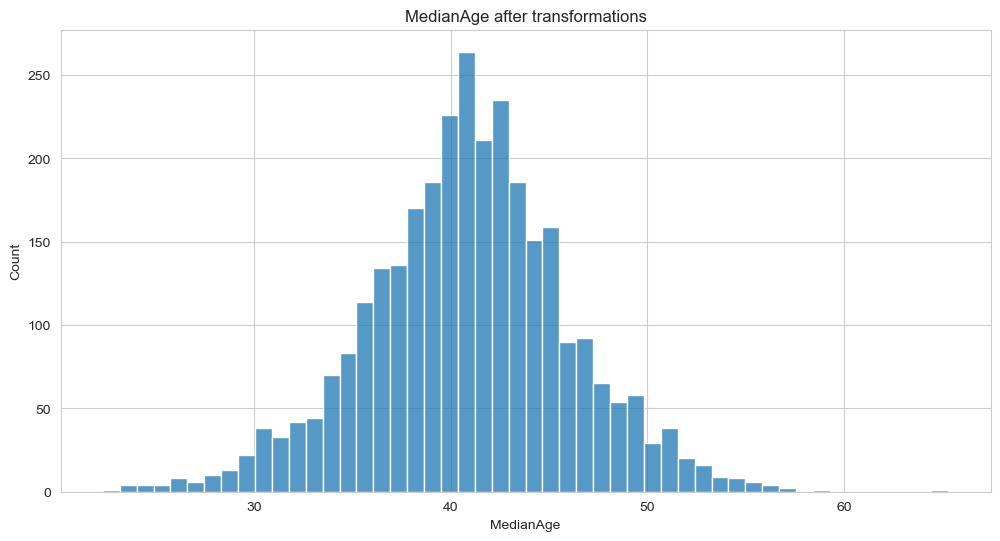

In [205]:
plt.figure(figsize=(12,6))

sns.histplot(clean_data['MedianAge'])
plt.title("MedianAge after transformations");

As I said before, after deleting the outliers, the distribution of MedianAge looks like a Gaussian. Next let's explotore variable "studyPerCap"


/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


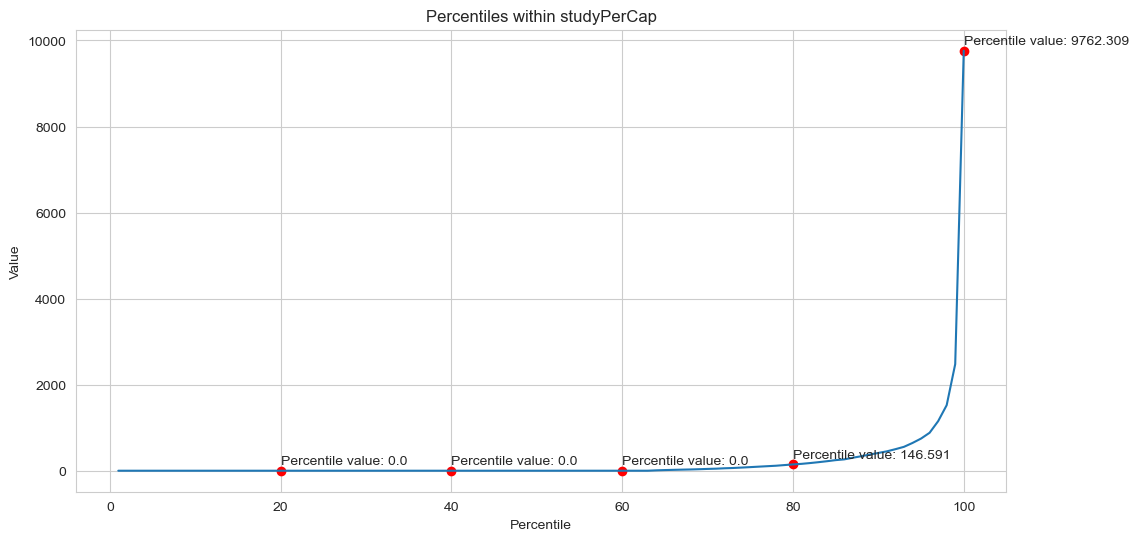

In [206]:
values = [np.percentile(clean_data['studyPerCap'],x) for x in percentile]
round_perc = [perc for perc in percentile if perc in range(0,101,20)]
round_values = [values[x-1] for x in round_perc]

plt.figure(figsize=(12,6))

sns.lineplot(x=percentile,y=values)
plt.scatter(round_perc, round_values,c='red')

for words in zip(round_perc,round_values):
    plt.text(words[0], words[1]+150, f"Percentile value: {np.round(words[1],3)}") 


plt.title("Percentiles within studyPerCap");
plt.xlabel("Percentile");
plt.ylabel("Value");



As we see there isn't a lot of data for most of the time. Since most of the data is equal to 0, a lot of them can be considered as an outlier. Also, since it is a variable that measures number of cancer-related clinical trials per county per capita, we cannot compare it to the population size. 

In [207]:
clean_data[clean_data['studyPerCap'] == clean_data['studyPerCap'].max()][['popEst2015','Geography','studyPerCap']]

,popEst2015,Geography,studyPerCap
383,4712,"Hamilton County, New York",9762.308998


There's also an impossible value. With county population of 4712, it's impossible that on 1 person, number of cancer-related trials comes down to 9762.30. We will delete this entry, or other impossible values.

In [208]:
clean_data.loc[np.where(clean_data['studyPerCap'] >= clean_data['popEst2015'])][['popEst2015','Geography','studyPerCap']]



,popEst2015,Geography,studyPerCap
383,4712,"Hamilton County, New York",9762.308998
471,2314,"Griggs County, North Dakota",3457.216940
666,2883,"Hitchcock County, Nebraska",4856.052723
927,2311,"Rich County, Utah",3894.418001
1310,7687,"Kingman County, Kansas",8585.924288


In [209]:
clean_data = clean_data.loc[np.where(clean_data['studyPerCap'] <= clean_data['popEst2015'])]

In [210]:
clean_data['studyPerCap'].describe()

count    3042.000000
mean      145.610157
std       460.110766
min         0.000000
25%         0.000000
50%         0.000000
75%        81.987937
max      9439.200444
Name: studyPerCap, dtype: float64

However, there will be still a lot of zeros. We will try to change this feature into a oridnal scale feature.

In [211]:
def ordinal_scale(x,column,data_frame):
    percentile = np.percentile(data_frame[column],75)
    mean = np.mean(data_frame[column])
    std = np.std(data_frame[column])

    if x == 0:
        return 0
    elif x <= percentile:
        return 1
    elif x <= mean:
        return 2
    elif x<= mean + std:
        return 3
    elif x <= mean + (2*std):
        return 4
    elif x <= mean + (3*std):
        return 5
    else:
        return 6
    

In [212]:
clean_data['studyPerCap_scaled'] = clean_data['studyPerCap'].apply(lambda x:ordinal_scale(x,'studyPerCap',clean_data))

In [213]:
clean_data.head()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,MedianAge,MedianAgeMale,MedianAgeFemale,Geography,AvgHouseholdSize,PercentMarried,PctNoHS18_24,PctHS18_24,PctBachDeg18_24,PctHS25_Over,PctBachDeg25_Over,PctEmployed16_Over,PctUnemployed16_Over,PctPrivateCoverage,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate,medianInc,cancDiag,cancDeath,studyPerCap_scaled
0,1397.0,469,164.9,489.8,61898,260131,11.2,499.748204,39.3,36.9,41.7,"Kitsap County, Washington",2.54,52.5,11.5,39.5,6.9,23.2,19.6,51.9,8.0,75.1,48.7,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831,61494.5,186.206872,554.650320,3
1,173.0,70,161.3,411.6,48127,43269,18.6,23.111234,33.0,32.2,33.7,"Kittitas County, Washington",2.34,44.5,6.1,22.4,7.5,26.0,22.7,55.9,7.8,70.2,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096,48021.6,250.109827,618.128571,1
2,102.0,50,174.7,349.7,49348,21026,14.6,47.560164,45.0,44.0,45.8,"Klickitat County, Washington",2.62,54.2,24.0,36.6,9.5,29.0,16.0,45.9,7.0,63.7,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488,48021.6,206.137255,420.520000,1
3,427.0,202,194.8,430.4,44243,75882,17.1,342.637253,42.8,42.2,43.4,"Lewis County, Washington",2.52,52.7,20.2,41.2,2.5,31.6,9.3,48.3,12.1,58.4,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841,42724.4,177.709602,375.653465,3
4,57.0,26,144.4,350.1,49955,10321,12.5,0.000000,48.3,47.8,48.9,"Lincoln County, Washington",2.34,57.8,14.9,43.0,2.0,33.4,15.0,48.2,4.8,61.6,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657,48021.6,181.070175,396.961538,0


Next, we will try to analyse the <b> AvgHouseholdSize </b> feautre.

In [214]:
clean_data['AvgHouseholdSize'].describe()

count    3042.000000
mean        2.479211
std         0.428671
min         0.022100
25%         2.370000
50%         2.500000
75%         2.630000
max         3.970000
Name: AvgHouseholdSize, dtype: float64

/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='AvgHouseholdSize', ylabel='Count'>

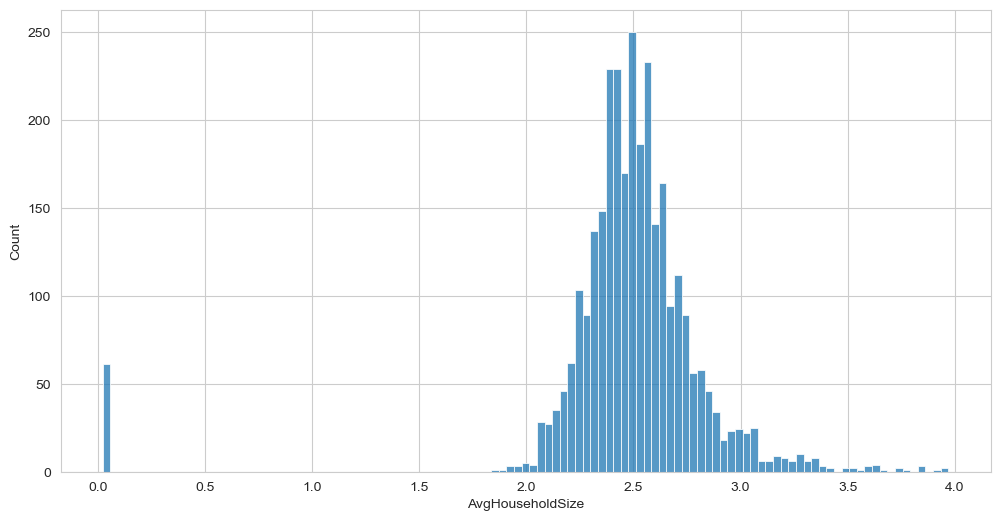

In [215]:
plt.figure(figsize=(12,6))

sns.histplot(clean_data['AvgHouseholdSize']) 

There's a few weird values. Minimum value of 0.022 is probably a wrong value, which we can observe by looking at the distribution of the plot. We will try to reduce the gap between the bar at the beggining and the "right" begginig of the distribution.

In [216]:
THRESHOLD = np.round(np.arange(0,0.5,0.1),3)
[f"Min value of AvgHousegold with threshold set as {x}: {clean_data[clean_data['AvgHouseholdSize']>x]['AvgHouseholdSize'].min()}" for x in THRESHOLD]

['Min value of AvgHousegold with threshold set as 0.0: 0.0221',
 'Min value of AvgHousegold with threshold set as 0.1: 1.86',
 'Min value of AvgHousegold with threshold set as 0.2: 1.86',
 'Min value of AvgHousegold with threshold set as 0.3: 1.86',
 'Min value of AvgHousegold with threshold set as 0.4: 1.86']

We will delete all of the values that have AvgHousehold Size less than 0.1.

In [217]:
clean_data = clean_data[clean_data['AvgHouseholdSize'] > 0.1]

/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


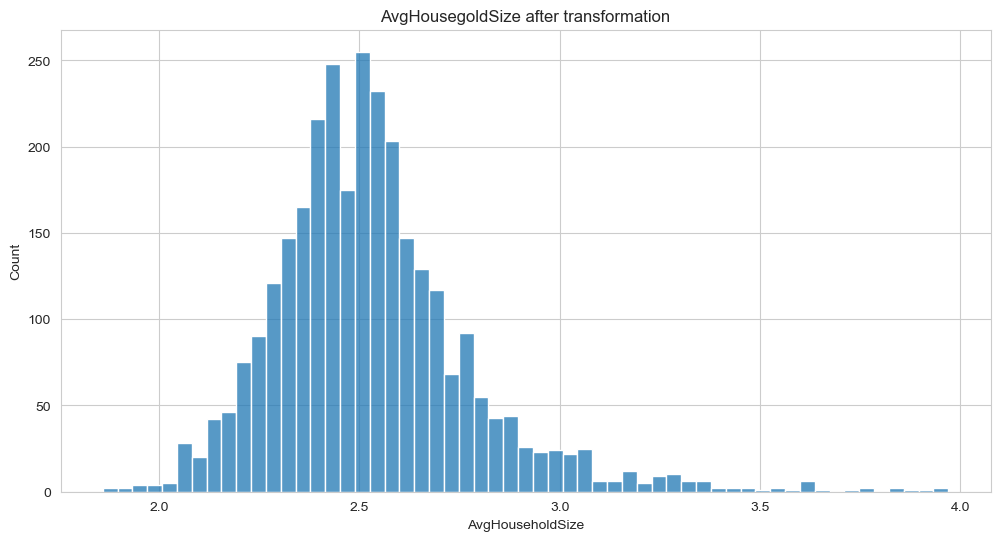

In [218]:
plt.figure(figsize=(12,6))

sns.histplot(clean_data['AvgHouseholdSize'])
plt.title("AvgHousegoldSize after transformation");

Now let's focus on variables that indicates the color of our skin. First let's check if there's a siginificant correlation between them, and the target value.

In [219]:
clean_data[['PctWhite','PctBlack','PctAsian','PctOtherRace','TARGET_deathRate']].corr()

,PctWhite,PctBlack,PctAsian,PctOtherRace,TARGET_deathRate
PctWhite,1.000000,-0.826187,-0.267686,-0.234672,-0.179370
PctBlack,-0.826187,1.000000,0.017565,-0.022837,0.260743
PctAsian,-0.267686,0.017565,1.000000,0.200290,-0.188214
PctOtherRace,-0.234672,-0.022837,0.200290,1.000000,-0.192003
TARGET_deathRate,-0.179370,0.260743,-0.188214,-0.192003,1.000000


As we expect, Race variables are strongly correlated with eachother. For those variables we will try to perform PCA in order to eliminate the correlation between them. 

In [220]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [221]:
scaler = StandardScaler()
cols_to_change = clean_data[['PctWhite','PctBlack','PctAsian','PctOtherRace']]

scaler.fit(cols_to_change)

scaled_cols = scaler.transform(cols_to_change)

pca = PCA(n_components=2)

pca.fit(scaled_cols)

cols_pca = pca.transform(scaled_cols)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")



Explained variance ratio: [0.47952615 0.29279177]


In [222]:
clean_data['RacePCA'] = cols_pca[:,0]

We will try to use the first dimension, since it's responsible for 47.95% of variance. However it might not be the best method to deal with this value. Later we will try do perform BoxCox transformation. Next, we will try to analyse <b> IncidenceRate</b>

/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='incidenceRate', ylabel='Count'>

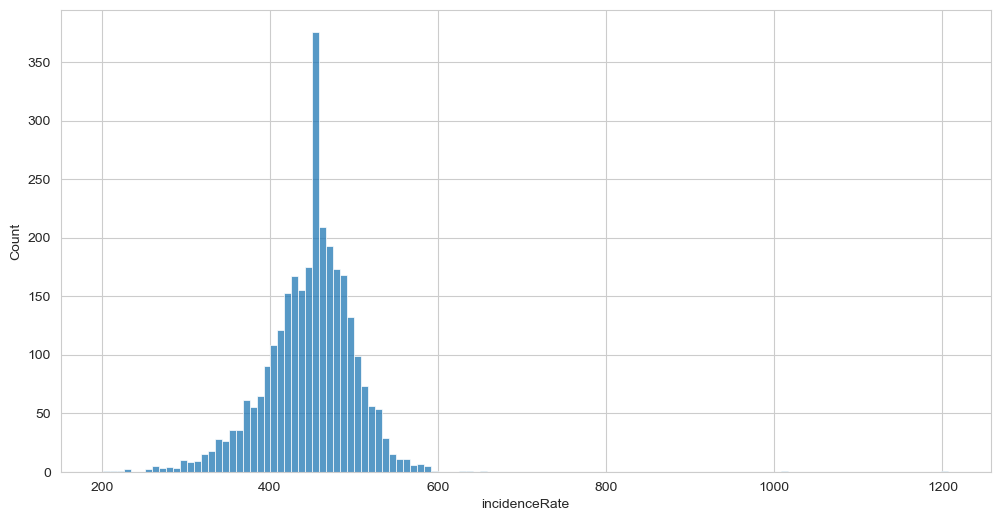

In [223]:
plt.figure(figsize=(12,6))

sns.histplot(clean_data['incidenceRate'])

In [224]:
clean_data['incidenceRate'].describe()

count    2981.000000
mean      447.868814
std        54.231786
min       201.300000
25%       420.100000
50%       453.549422
75%       480.200000
max      1206.900000
Name: incidenceRate, dtype: float64

The max value seems to be a bit off. We will replace those values with value 600. Since it's the end of our 'normal values' tail.

In [225]:
clean_data.loc[clean_data['incidenceRate']>600,'incidenceRate'] = 600

/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


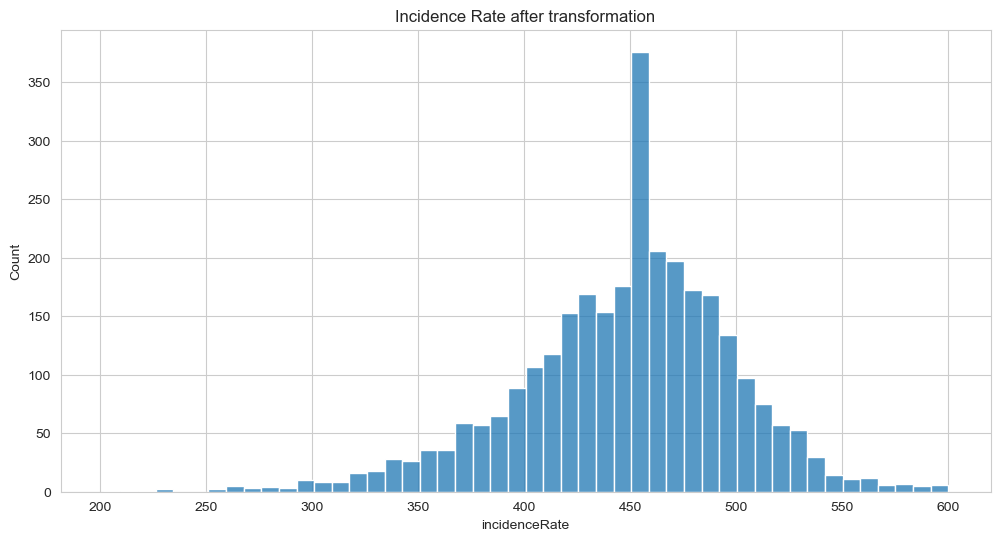

In [226]:
plt.figure(figsize=(12,6))

sns.histplot(clean_data['incidenceRate'])
plt.title("Incidence Rate after transformation");

Now let's focus on columns that are not skewed. Let's start with <b>Geography</b> variable.

In [227]:
not_analysed_cols = [col for col in clean_data.columns if col not in skew_cols]

print(f"Number of unanalysed columns: {len(not_analysed_cols)}")
print(not_analysed_cols)

Number of unanalysed columns: 17
['TARGET_deathRate', 'MedianAgeMale', 'MedianAgeFemale', 'Geography', 'PctHS18_24', 'PctHS25_Over', 'PctEmployed16_Over', 'PctPrivateCoverage', 'PctPrivateCoverageAlone', 'PctEmpPrivCoverage', 'PctPublicCoverage', 'PctPublicCoverageAlone', 'medianInc', 'cancDiag', 'cancDeath', 'studyPerCap_scaled', 'RacePCA']


First, lets extract the county and state value.

In [228]:
clean_data['State']=[state[1] for state in clean_data['Geography'].str.split(", ")]
clean_data['County'] = [state[0] for state in clean_data['Geography'].str.split(", ")]

In [229]:
print(f"Shape of data: {clean_data.shape[0]}")
print(f"Number of unique states: {len(clean_data['State'].drop_duplicates())}")
print(f"Number of duplicated rows: {len(clean_data.loc[clean_data['Geography'].str.lower().str.strip().duplicated()])}")

Shape of data: 2981
Number of unique states: 51
Number of duplicated rows: 0


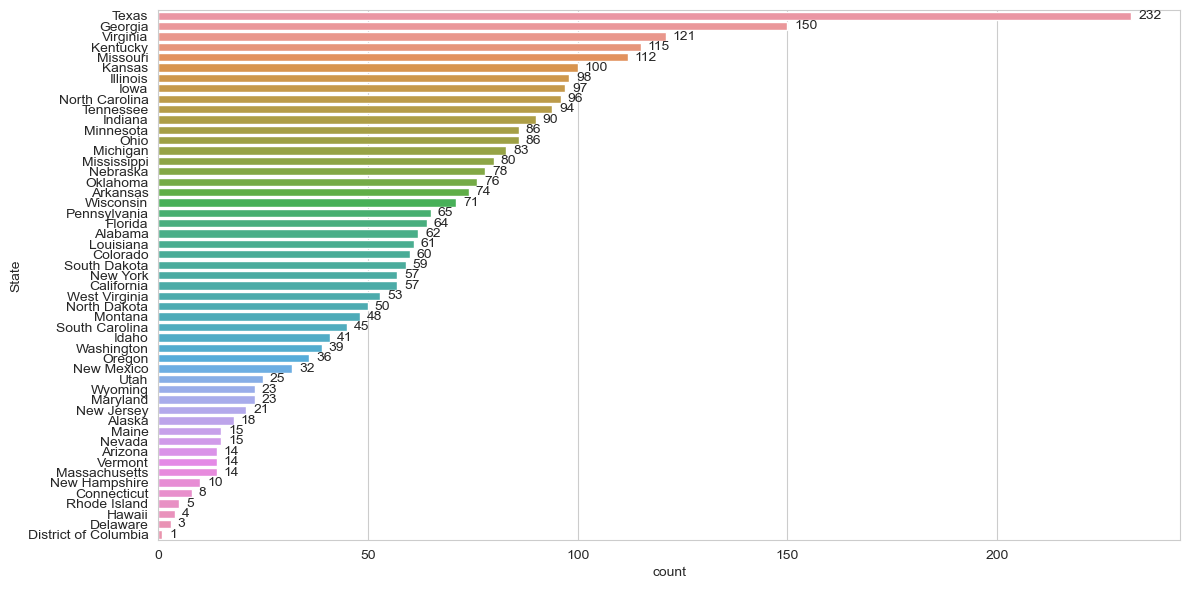

In [230]:
plt.figure(figsize=(12,6))

fig = sns.countplot(data=clean_data, y='State',order=clean_data['State'].value_counts().index)

fig.bar_label(fig.containers[0],label_type='edge',padding = 5)


plt.tight_layout()

not_analysed_cols.remove('Geography')

In [231]:
print(not_analysed_cols)

['TARGET_deathRate', 'MedianAgeMale', 'MedianAgeFemale', 'PctHS18_24', 'PctHS25_Over', 'PctEmployed16_Over', 'PctPrivateCoverage', 'PctPrivateCoverageAlone', 'PctEmpPrivCoverage', 'PctPublicCoverage', 'PctPublicCoverageAlone', 'medianInc', 'cancDiag', 'cancDeath', 'studyPerCap_scaled', 'RacePCA']


Now let's focus on features connected with median Age.

In [232]:
clean_data[['MedianAgeMale','MedianAgeFemale','MedianAge']].corr() 

,MedianAgeMale,MedianAgeFemale,MedianAge
MedianAgeMale,1.000000,0.933426,0.976259
MedianAgeFemale,0.933426,1.000000,0.969552
MedianAge,0.976259,0.969552,1.000000


Since variable MedianAge is highly correlated with median age of females and males, we will just drop those two features.

In [233]:
#clean_data = clean_data.drop(['MedianAgeMale','MedianAgeFemale'],axis=1)
not_analysed_cols = [col for col in not_analysed_cols if col not in ('MedianAgeMale','MedianAgeFemale')]

In [234]:
print(not_analysed_cols)

['TARGET_deathRate', 'PctHS18_24', 'PctHS25_Over', 'PctEmployed16_Over', 'PctPrivateCoverage', 'PctPrivateCoverageAlone', 'PctEmpPrivCoverage', 'PctPublicCoverage', 'PctPublicCoverageAlone', 'medianInc', 'cancDiag', 'cancDeath', 'studyPerCap_scaled', 'RacePCA']


Now let's focus on variables connected with health coverage.

In [235]:
HEALTH_COVE = [col for col in not_analysed_cols if 'Coverage' in col]

In [236]:
clean_data[HEALTH_COVE].corr()

,PctPrivateCoverage,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone
PctPrivateCoverage,1.000000,0.833883,0.826815,-0.722327,-0.888125
PctPrivateCoverageAlone,0.833883,1.000000,0.830534,-0.771428,-0.771159
PctEmpPrivCoverage,0.826815,0.830534,1.000000,-0.780451,-0.730334
PctPublicCoverage,-0.722327,-0.771428,-0.780451,1.000000,0.866356
PctPublicCoverageAlone,-0.888125,-0.771159,-0.730334,0.866356,1.000000


As we see, we have another set of highly correlated features. Let's see how well the PCA will perform.

In [237]:
scaler = StandardScaler()
cols_to_change = clean_data[HEALTH_COVE]

scaler.fit(cols_to_change)

scaled_cols = scaler.transform(cols_to_change)

pca = PCA(n_components=2)

pca.fit(scaled_cols)

cols_pca = pca.transform(scaled_cols)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")



Explained variance ratio: [0.84183885 0.06566764]


As we see first component is responsible for 84.18% of variance which is a very good result. We will use the first component do describe the health coverage.

In [238]:
clean_data['HEALTH_PCA'] = cols_pca[:,0]

In [239]:
not_analysed_cols = [col for col in not_analysed_cols if col not in HEALTH_COVE]

Now let's focus on features connected with education. First, let's check the correlation between those features.

In [240]:
EDU = ['PctNoHS18_24','PctHS18_24','PctBachDeg18_24','PctHS25_Over','PctBachDeg25_Over']

In [241]:
clean_data[EDU].corr()

,PctNoHS18_24,PctHS18_24,PctBachDeg18_24,PctHS25_Over,PctBachDeg25_Over
PctNoHS18_24,1.000000,0.092658,-0.382521,0.222791,-0.399428
PctHS18_24,0.092658,1.000000,-0.393090,0.439263,-0.406339
PctBachDeg18_24,-0.382521,-0.393090,1.000000,-0.386604,0.600074
PctHS25_Over,0.222791,0.439263,-0.386604,1.000000,-0.742480
PctBachDeg25_Over,-0.399428,-0.406339,0.600074,-0.742480,1.000000


There's strong negative correlation between "PctHS25_Over" and "PctBachDeg25_Over".

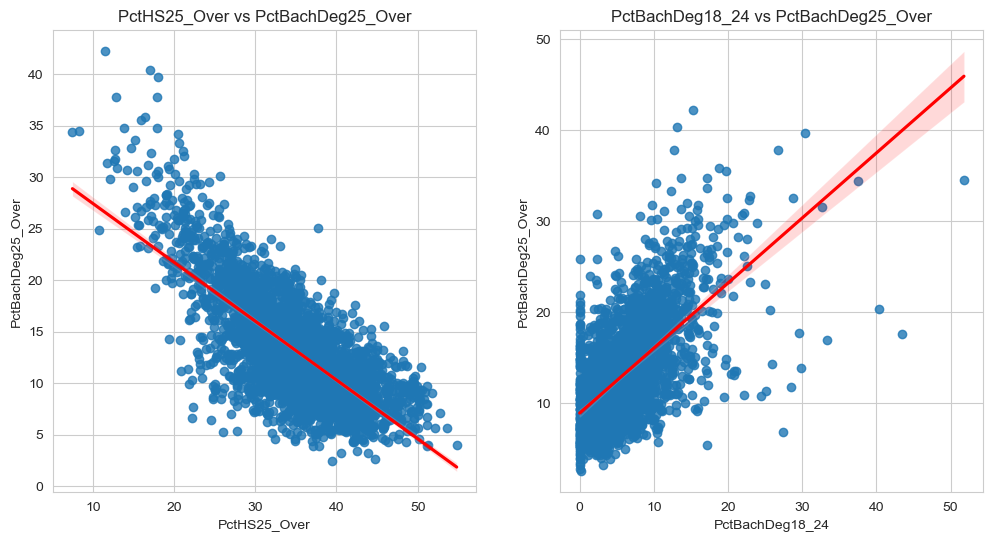

In [242]:
fig,ax = plt.subplots(1,2,figsize=(12,6))

sns.regplot(data = clean_data, x='PctHS25_Over', y='PctBachDeg25_Over',line_kws={'color':'red'},ax=ax[0])
ax[0].set_title("PctHS25_Over vs PctBachDeg25_Over");

sns.regplot(data = clean_data, x='PctBachDeg18_24', y='PctBachDeg25_Over',line_kws={'color':'red'},ax=ax[1])
ax[1].set_title("PctBachDeg18_24 vs PctBachDeg25_Over");


In terms of the plot on the left, we can say that in a county where more people have high school as their highest level of education, fewer people have a Bachelor's degree (and vice versa). However in terms of plot on the right, the more people in age between 18-24 were having degree, the most people were having Bachelors degree after 25 years of age. Since both of those plots contains feature <b> PctBachDeg25_Over</b> we will just drop this feature.

In [243]:
clean_data = clean_data.drop("PctBachDeg25_Over",axis=1)

In [244]:
not_analysed_cols = [col for col in not_analysed_cols if col not in EDU]
print(not_analysed_cols)

['TARGET_deathRate', 'PctEmployed16_Over', 'medianInc', 'cancDiag', 'cancDeath', 'studyPerCap_scaled', 'RacePCA']


Now let's focus on Employment status.

In [245]:
EMPL = ['PctEmployed16_Over','PctUnemployed16_Over']

clean_data[EMPL].corr()

,PctEmployed16_Over,PctUnemployed16_Over
PctEmployed16_Over,1.000000,-0.631247
PctUnemployed16_Over,-0.631247,1.000000


/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


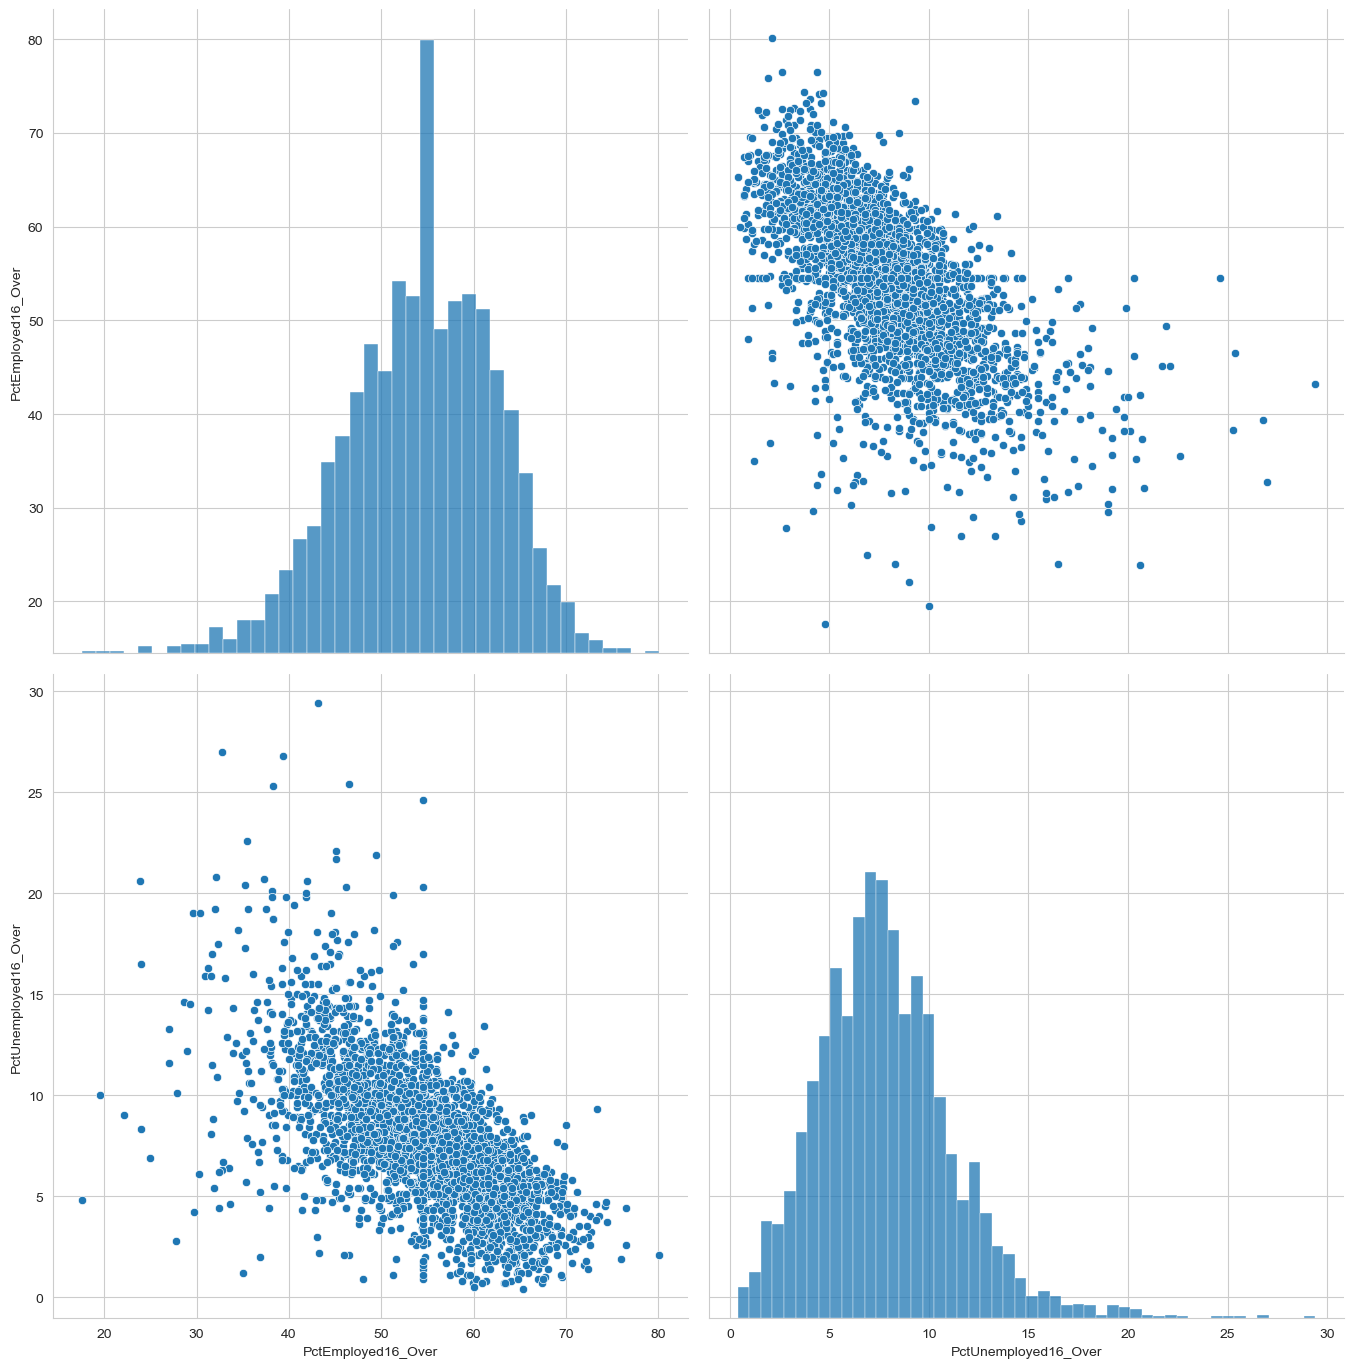

In [246]:
g = sns.pairplot(clean_data[EMPL])
g.fig.set_size_inches(15,15)

We will create a new feature, that will represent the difference between those two groups. 

In [247]:
clean_data['DIFF_EMPL'] = clean_data['PctEmployed16_Over'] - clean_data['PctUnemployed16_Over']

In [248]:
clean_data['DIFF_EMPL'].describe()

count    2981.000000
mean       46.346092
std        10.653057
min         3.300000
25%        39.500000
50%        46.900000
75%        53.800000
max        78.000000
Name: DIFF_EMPL, dtype: float64

/opt/anaconda3/envs/moje_srodowisko/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


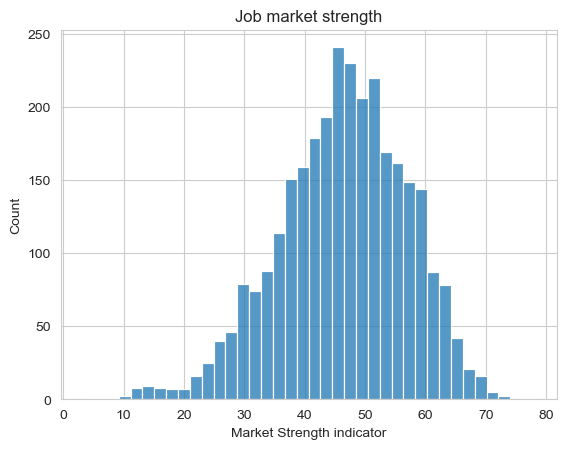

In [249]:
sns.histplot(clean_data['DIFF_EMPL'])
plt.title("Job market strength");
plt.xlabel("Market Strength indicator");

In [250]:
not_analysed_cols = [col for col in not_analysed_cols if col not in EMPL]
print(not_analysed_cols)

['TARGET_deathRate', 'medianInc', 'cancDiag', 'cancDeath', 'studyPerCap_scaled', 'RacePCA']


Since, we've gone through every variable, let's try to analyse them with comparision to the target variable.

In [251]:
num_cols = [col for col in clean_data.columns if clean_data[col].dtype in ['float64','int64']]

In [259]:
pairs = []

for col in num_cols:
    for col_two in num_cols:
        pair = [col, col_two]
        if col == col_two:
            pass
        else:
            if sorted(pair) in pairs:
                pass
            else:
                corr = np.corrcoef(clean_data[col], clean_data[col_two])[1][0]
                if abs(corr) >= 0.8:
                    pair.append(round(corr,2))
                    pairs.append(pair)

In [261]:
corr_df = pd.DataFrame(pairs).rename(columns={0:'1_st_feature',1:'2_nd_feature',2:'Correlation'})
corr_df.head()

,1_st_feature,2_nd_feature,Correlation
0,avgAnnCount,avgDeathsPerYear,0.94
1,avgAnnCount,popEst2015,0.93
2,avgDeathsPerYear,avgAnnCount,0.94
3,avgDeathsPerYear,popEst2015,0.98
4,medIncome,medianInc,0.91


With how many features are particular feature correlated?

In [265]:
print(f"Total number of features: {len(num_cols)}")
corr_df['1_st_feature'].value_counts()

Total number of features: 37


1_st_feature
HEALTH_PCA                 6
PctPrivateCoverage         5
medianInc                  3
PctPublicCoverageAlone     3
PctEmpPrivCoverage         3
PctPrivateCoverageAlone    3
avgDeathsPerYear           2
RacePCA                    2
PctBlack                   2
PctWhite                   2
PctPublicCoverage          2
avgAnnCount                2
MedianAgeFemale            2
MedianAgeMale              2
MedianAge                  2
povertyPercent             2
popEst2015                 2
DIFF_EMPL                  2
PctUnemployed16_Over       1
PctEmployed16_Over         1
PercentMarried             1
PctMarriedHouseholds       1
medIncome                  1
Name: count, dtype: int64

In [266]:
corr_df[corr_df['1_st_feature']=='HEALTH_PCA']

,1_st_feature,2_nd_feature,Correlation
44,HEALTH_PCA,PctPrivateCoverage,-0.93
45,HEALTH_PCA,PctPrivateCoverageAlone,-0.92
46,HEALTH_PCA,PctEmpPrivCoverage,-0.91
47,HEALTH_PCA,PctPublicCoverage,0.90
48,HEALTH_PCA,PctPublicCoverageAlone,0.93
49,HEALTH_PCA,medianInc,-0.82
